Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings('ignore')

Data Loading & Basic Info

In [2]:
df = pd.read_csv('output.csv')
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {len(df):,}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst few rows:")
print(df.head())



Dataset Shape: (68427, 22)
Total Records: 68,427

Column Names:
['Row ID', 'Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Regional Manager', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Returned', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order']

Data Types:
Row ID                int64
Order ID             object
Ship Mode            object
Customer ID          object
Customer Name        object
Segment              object
Country              object
City                 object
State                object
Postal Code          object
Region               object
Regional Manager     object
Product ID           object
Category             object
Sub-Category         object
Product Name         object
Returned             object
Sales               float64
Quantity              int64
Discount            float64
Profit              float64
Order                object
dtype: object

First few rows:
 

Preprocessing

In [3]:
df['Order'] = pd.to_datetime(df['Order'], format='%d/%m/%Y')
df['Year'] = df['Order'].dt.year
df['YearMonth'] = df['Order'].dt.to_period('M').dt.to_timestamp()
categories = df['Category'].unique()

PART 1: VISUALIZATIONS

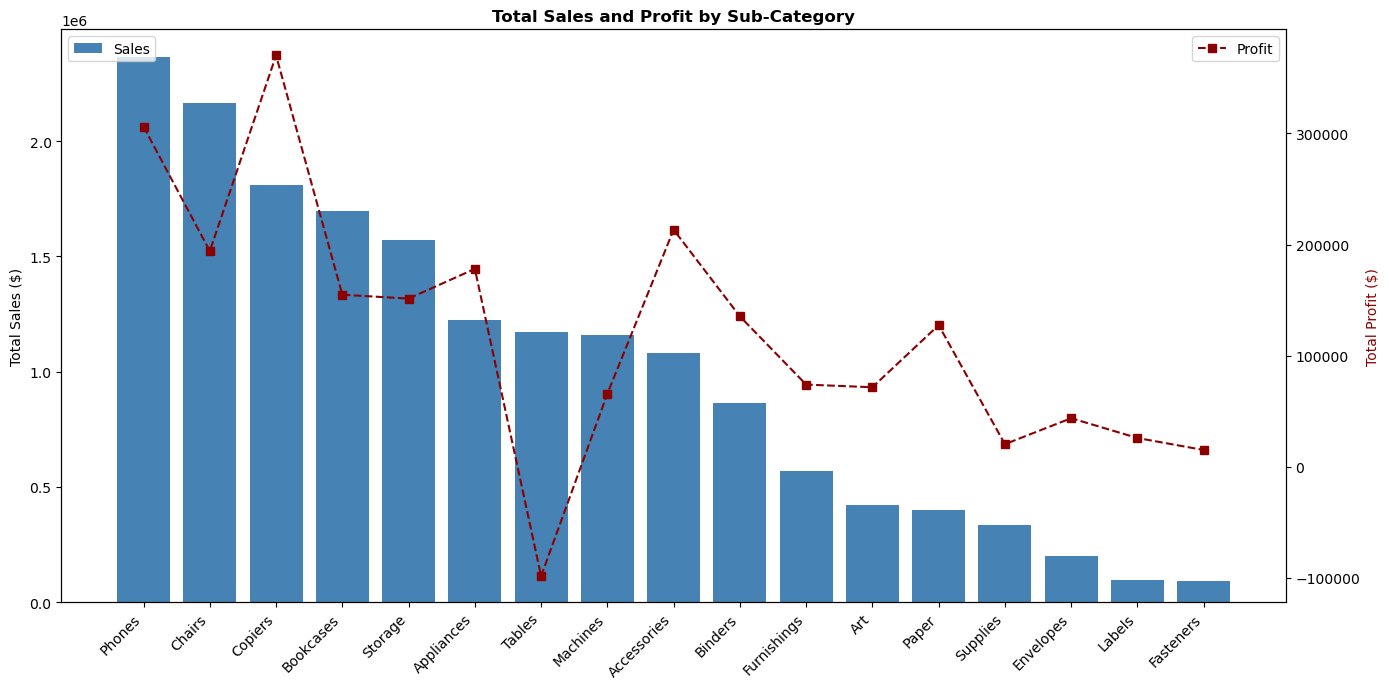

In [4]:
# VISUALIZATION 1: Sales & Profit by Sub-Category
sub_data = df.groupby('Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'}).sort_values('Sales', ascending=False)
x_pos = np.arange(len(sub_data))

plt.figure(figsize=(14, 7))
plt.bar(x_pos, sub_data['Sales'], color='steelblue', label='Sales')
plt.xticks(x_pos, sub_data.index, rotation=45, ha='right')
plt.ylabel('Total Sales ($)')
plt.legend(loc='upper left')

plt.twinx() # Switches plt state to the secondary y-axis
plt.plot(x_pos, sub_data['Profit'], color='darkred', marker='s', linestyle='--', label='Profit')
plt.ylabel('Total Profit ($)', color='darkred')
plt.title('Total Sales and Profit by Sub-Category', fontweight='bold')
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('1_sales_&_profit.png', dpi=300)
plt.show()

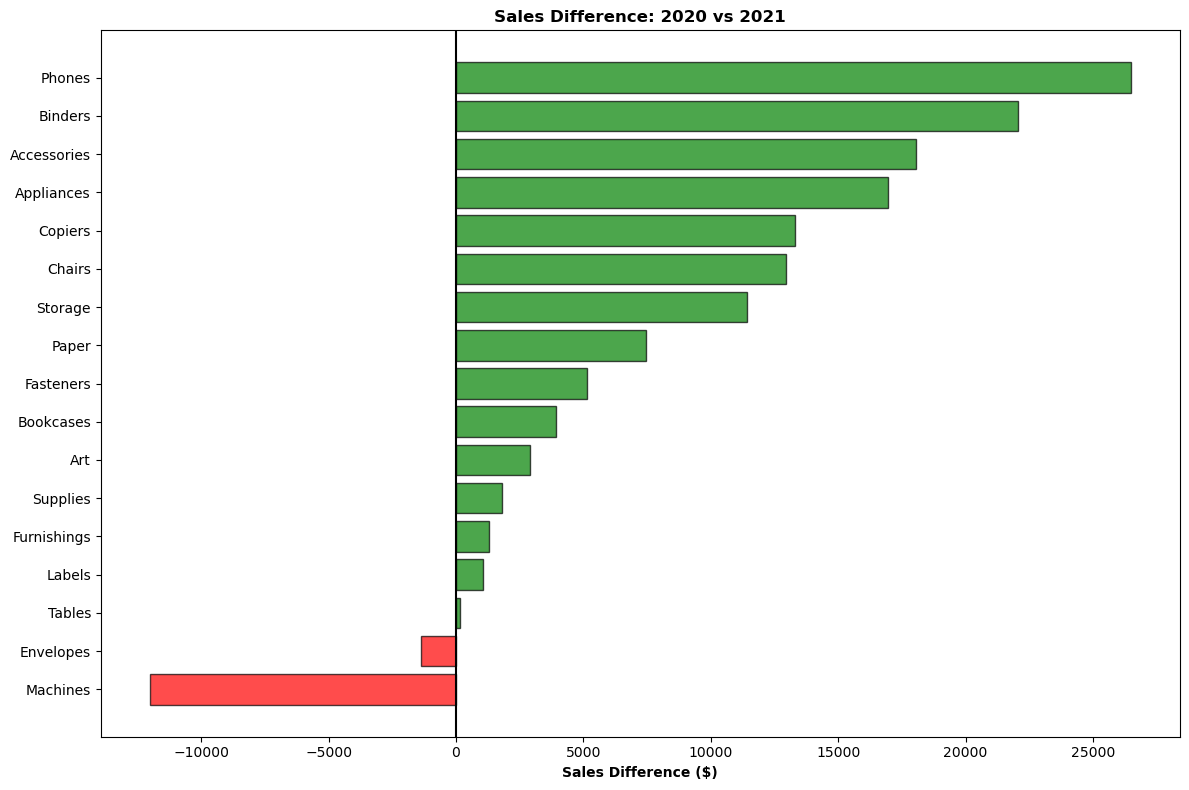

In [5]:
# VISUALIZATION 2: 2020 vs 2021 Sales Difference 
df_20 = df[df['Year'] == 2020].groupby('Sub-Category')['Sales'].sum()
df_21 = df[df['Year'] == 2021].groupby('Sub-Category')['Sales'].sum()
diff = (df_21.reindex(df_20.index, fill_value=0) - df_20).sort_values()

plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in diff]
plt.barh(diff.index, diff.values, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Sales Difference ($)', fontweight='bold')
plt.title('Sales Difference: 2020 vs 2021', fontweight='bold')
plt.axvline(x=0, color='black', linewidth=1.5)

plt.tight_layout()
plt.savefig('02_sales_difference.png', dpi=300)
plt.show()

PART 2: Regression Analysis

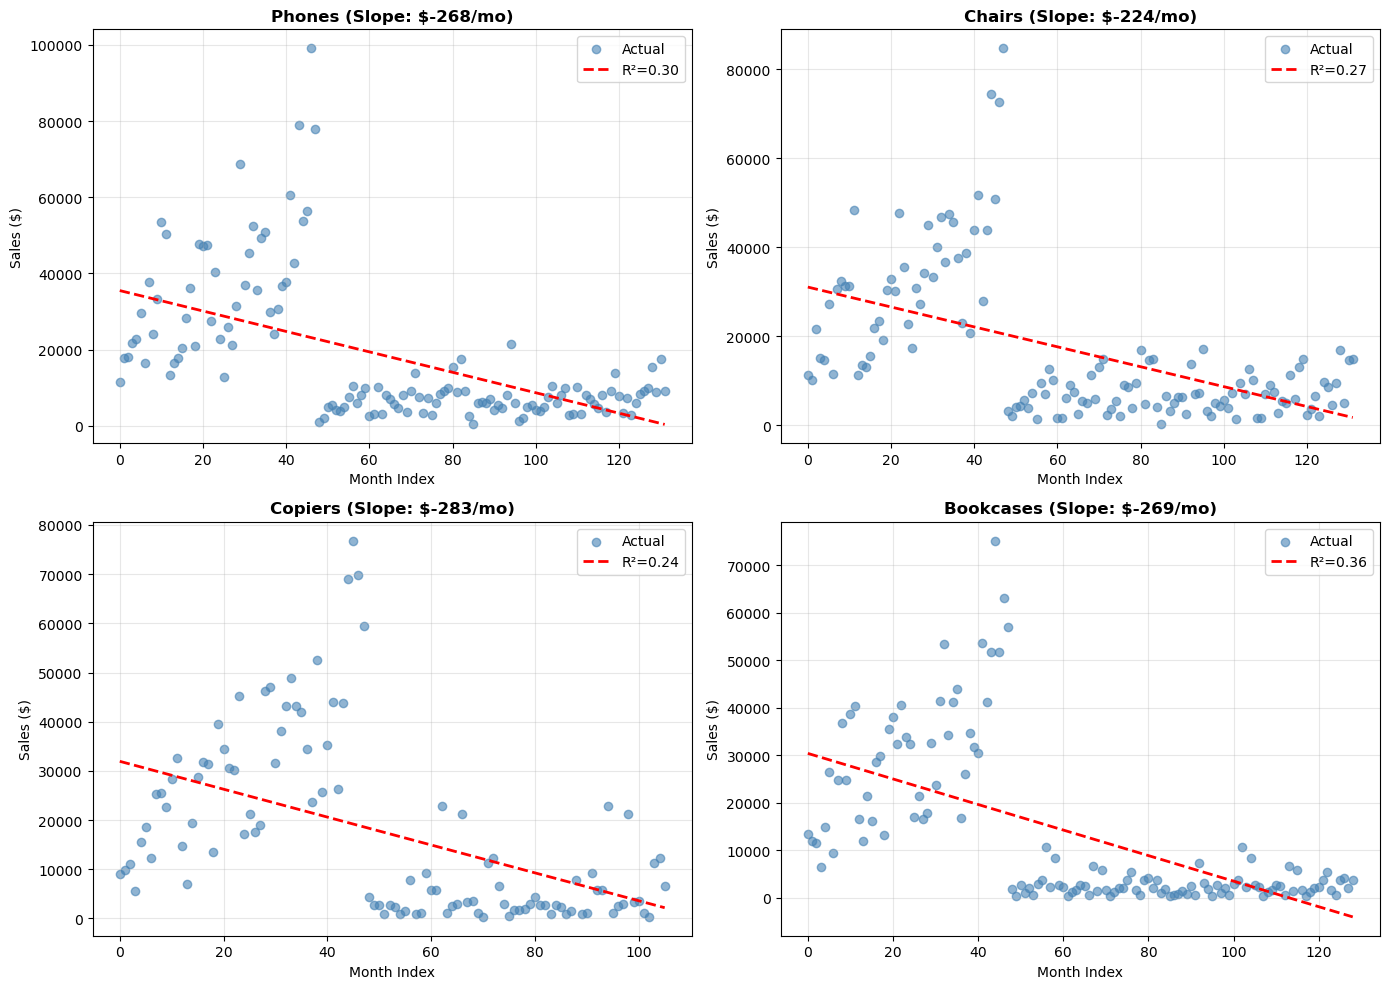

In [6]:
# VISUALIZATION 3: Regression Lines for Top 4 Sub-Categories
top_subcats = df.groupby('Sub-Category')['Sales'].sum().nlargest(4).index

plt.figure(figsize=(14, 10))
for i, subcat in enumerate(top_subcats, 1):
    plt.subplot(2, 2, i)
    d = df[df['Sub-Category'] == subcat].groupby('YearMonth')['Sales'].sum().reset_index()
    x = np.arange(len(d))
    y = d['Sales'].values
    slope, intercept, r_value, _, _ = stats.linregress(x, y)
    
    plt.scatter(x, y, alpha=0.6, color='steelblue', label='Actual')
    plt.plot(x, slope * x + intercept, 'r--', linewidth=2, label=f'R²={r_value**2:.2f}')
    
    plt.title(f'{subcat} (Slope: ${slope:.0f}/mo)', fontweight='bold')
    plt.xlabel('Month Index')
    plt.ylabel('Sales ($)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_regression_analysis.png', dpi=300)
plt.show()

PART 4: Time Series Analysis

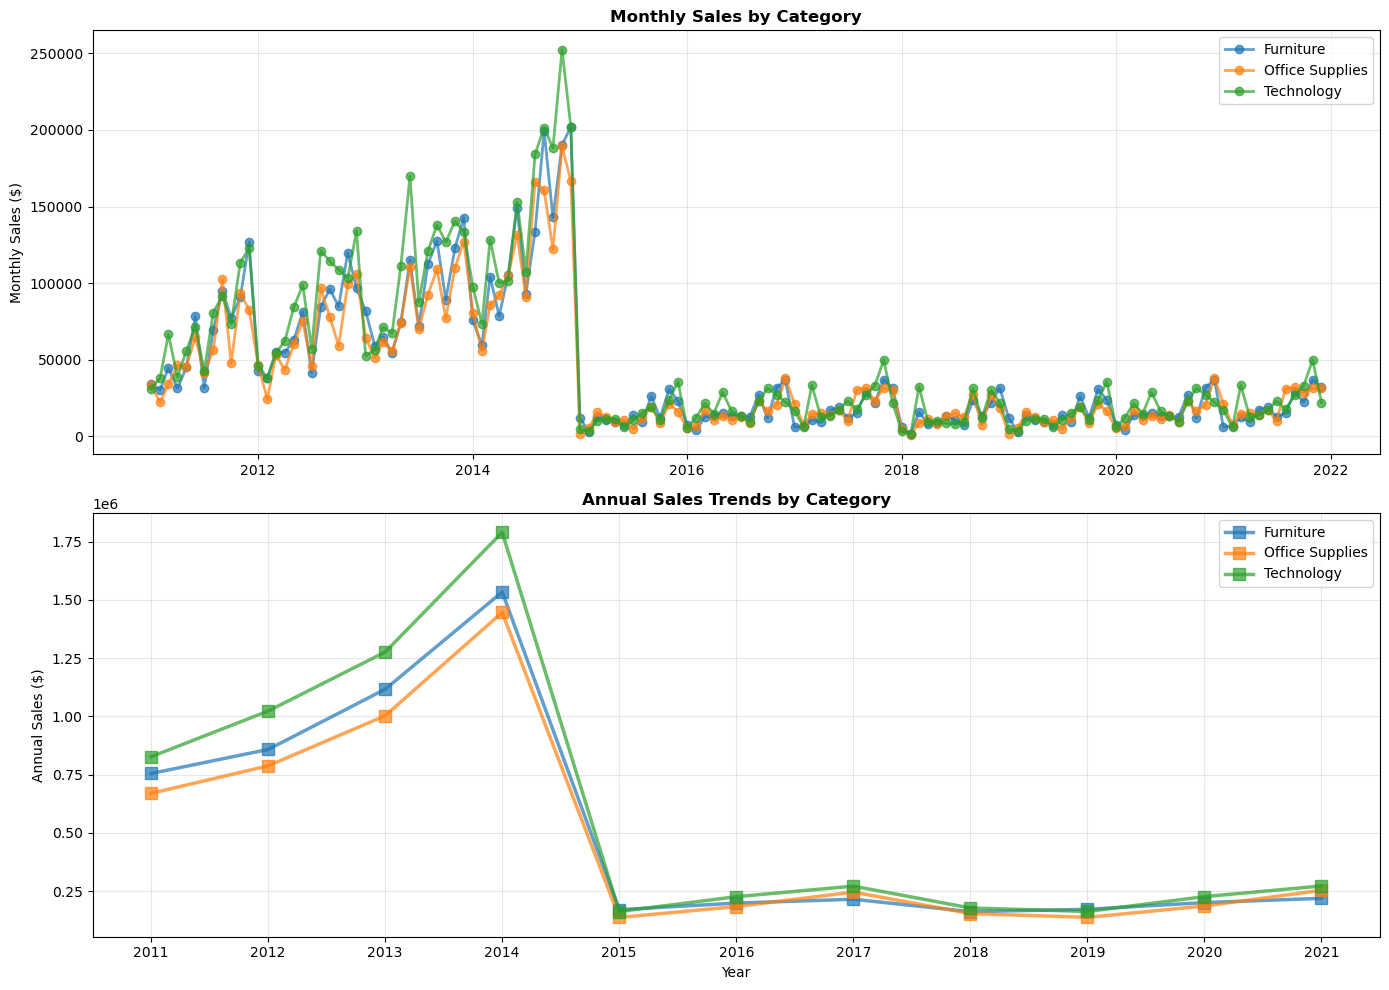

In [7]:
# VISUALIZATION 4: Time Series Trends
plt.figure(figsize=(14, 10))

# Top Subplot: Monthly
plt.subplot(2, 1, 1)
for cat in categories:
    d = df[df['Category'] == cat].groupby('YearMonth')['Sales'].sum()
    plt.plot(d.index, d.values, marker='o', linewidth=2, label=cat, alpha=0.7)
plt.title('Monthly Sales by Category', fontweight='bold')
plt.ylabel('Monthly Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Bottom Subplot: Yearly
plt.subplot(2, 1, 2)
for cat in categories:
    d = df[df['Category'] == cat].groupby('Year')['Sales'].sum()
    plt.plot(d.index, d.values, marker='s', linewidth=2.5, markersize=8, label=cat, alpha=0.7)
plt.title('Annual Sales Trends by Category', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Annual Sales ($)')
plt.xticks(df['Year'].unique())
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('04_time_series.png', dpi=300)
plt.show()

 TIME SERIES DECOMPOSITION & ARIMA FORECASTING

A. Decomposition

<Figure size 1200x800 with 0 Axes>

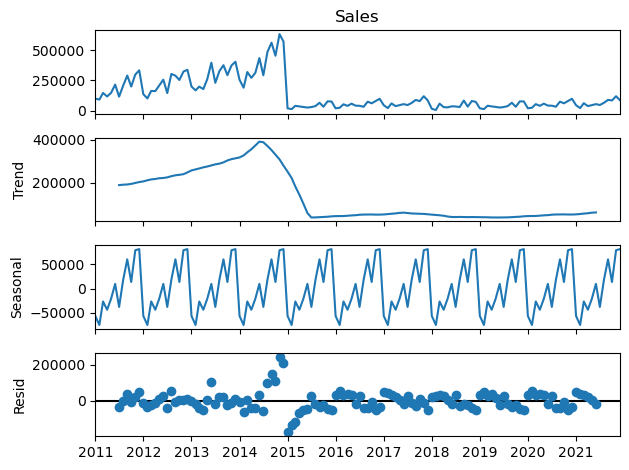

In [8]:
# Using the total monthly sales for this analysis
monthly_sales = df.groupby('YearMonth')['Sales'].sum()

result = seasonal_decompose(monthly_sales, model='additive', period=12)
plt.figure(figsize=(12, 8))
result.plot()
plt.tight_layout()
plt.savefig('05_decomposition.png', dpi=300)
plt.show()

B. ARIMA Forcasting

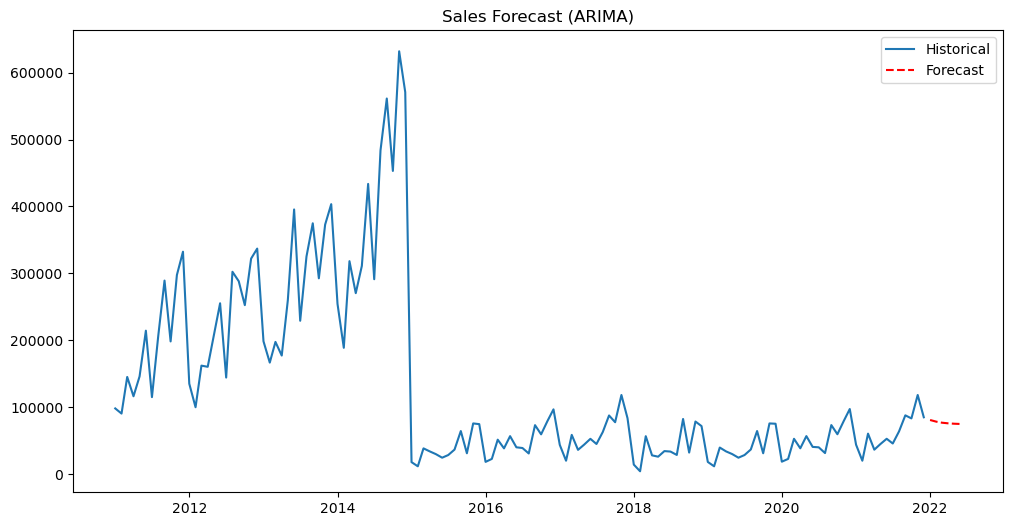

In [9]:
# Fitting on existing data and forecast 6 months ahead
model = ARIMA(monthly_sales, order=(1, 1, 1)) 
model_fit = model.fit()
forecast = model_fit.forecast(steps=6)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, label='Historical')
# Adding forecast to the plot
forecast_index = pd.date_range(start=monthly_sales.index[-1], periods=7, freq='MS')[1:]
plt.plot(forecast_index, forecast, label='Forecast', color='red', linestyle='--')
plt.title('Sales Forecast (ARIMA)')
plt.legend()
plt.savefig('06_arima_forecast.png', dpi=300)
plt.show()